In [ ]:
import os
import sys
from pathlib import Path

REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
os.chdir(REPO_ROOT)

import matplotlib.pyplot as plt
import numpy as np
from omegaconf import OmegaConf

from src.builder import build_image_loader, validate_config

In [2]:
cfg = OmegaConf.load(REPO_ROOT / "configs" / "default.yaml")
validate_config(cfg)

dataset = build_image_loader(cfg)
print("train_shape :", dataset.train_shape)
print("in_channels :", dataset.in_channels)
for a in (0, 1, 2):
    print(f"axis {a} pool size: {len(dataset._images[a])}")

train_shape : (64, 64, 64)
in_channels : 1
axis 0 pool size: 2
axis 1 pool size: 2
axis 2 pool size: 2


In [3]:
def to_display(t):
    """(C, H, W) in [-1, 1] -> (H, W) or (H, W, 3) in [0, 1] for matplotlib."""
    img = (t.numpy() + 1.0) / 2.0
    img = np.clip(img, 0.0, 1.0)
    if img.shape[0] == 1:
        return img[0]
    return np.transpose(img, (1, 2, 0))


def show_axis_grid(dataset, axis, count=6):
    batch = dataset.sample(axis=axis, count=count)
    fig, axes = plt.subplots(1, count, figsize=(2 * count, 2.2))
    cmap = "gray" if dataset.in_channels == 1 else None
    for i, ax in enumerate(axes):
        ax.imshow(to_display(batch[i]), cmap=cmap, vmin=0.0, vmax=1.0)
        ax.set_xticks([])
        ax.set_yticks([])
    fig.suptitle(f"axis {axis}  -  shape {tuple(batch.shape)}", y=1.02)
    plt.tight_layout()
    plt.show()

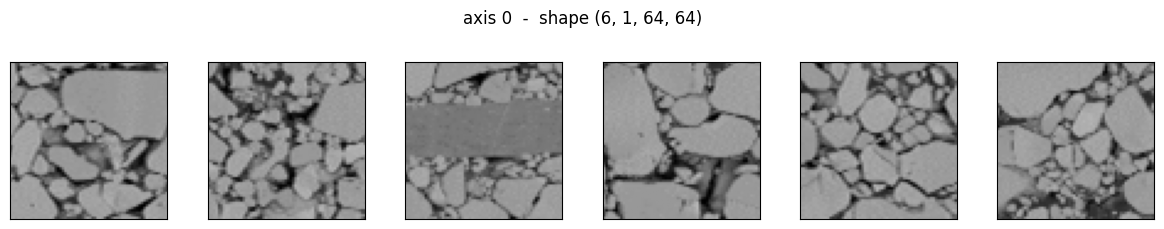

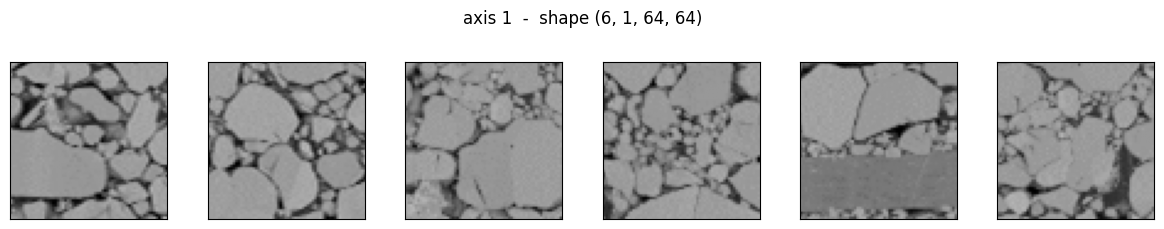

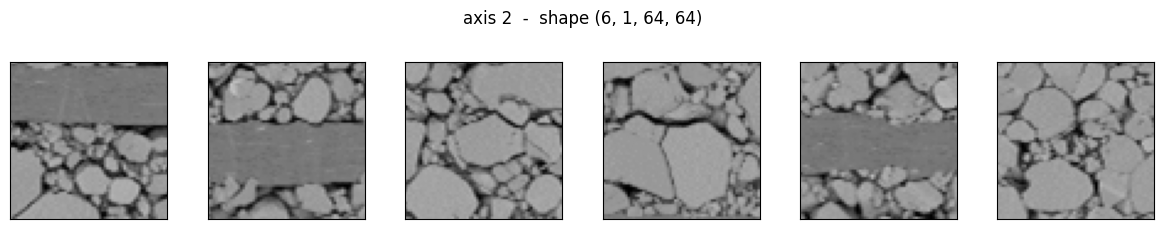

In [4]:
for axis in (0, 1, 2):
    show_axis_grid(dataset, axis=axis, count=6)